## Calculating CARs_NN via cohesin enrichments

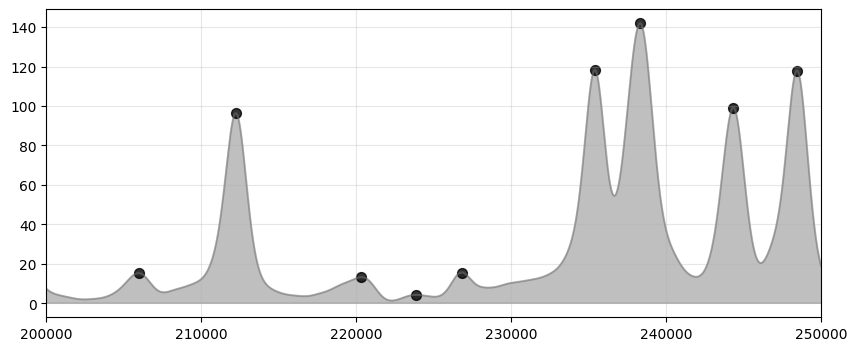

In [ ]:
# Analyzing Cohesin Peaks in Yeast Genome
# This script :
#   - reads a bigwig file containing cohesin enrichment data
#   - smooths the data 
#   - identifies peaks
#   - visualizes the results


# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Bio
import bioframe
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d


# ── Global Values ──────────────────────────────────────────────────────────────────

# Chromosomes
CHROMS = [
    'chrI',
    'chrII',
    'chrIII',
    'chrIV',
    'chrV',
    'chrVI',
    'chrVII',
    'chrVIII',
    'chrIX',
    'chrX',
    'chrXI',
    'chrXII',
    'chrXIII',
    'chrXIV',
    'chrXV',
    'chrXVI'
]

# Cohesin :
DATA_COHE = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/GSM4577764_Mcd1p_WT.bigwig"


# ── Window ──────────────────────────────────────────────────────────────────

# Reading Data:
data = DATA_COHE

# Choosing the region of reads
chrom   = 'chrII'
df1     = bioframe.read_bigwig(data, chrom)
xlims   = [200_000, 250_000]
SIGMA   = 500


# ── Calculations ──────────────────────────────────────────────────────────────────

# Note that bins have different sizes, in this case I interploate but you may also rebin to the scale is meaningful for your simulations
pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
enrichment = df1['value'].values

# Regular grid (1 bp spacing here)
pos_uniform = np.arange(pos.min(), pos.max()+1)

# Interpolate
f = interp1d(pos, enrichment,
             kind='linear',
             bounds_error=False,
             fill_value='extrapolate')
enrichment_uniform = f(pos_uniform)

# Smoothing -> sigma is the smooting parameter
# Based on the biological value : typically, beatween each car there is between 10 and 20 kb
enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=SIGMA)

# Finding Peaks using Scipy
# With a minimum height of min_h and a minimum distance of min_d between peaks
min_h = 1
min_d = 10
prominence = 0.050
peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)


# ── Plot ──────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 4))
plt.plot(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.fill_between(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.scatter(pos_uniform[peaks], enrichment_smooth[peaks], color="black", s=50, alpha=0.8)
plt.xlim(xlims)
plt.grid(True, which="both", alpha=0.30)
plt.show()

In [2]:
# From the plot, we can see that the peaks are well detected. 
# We can now create a dataframe with the peaks positions and heights.
# The dataframe will be used to create a new dataframe with the nearest neighbor CARs for each chromosome.


# ── Calculating File ──────────────────────────────────────────────────────────────────

# Create a dataframe with the peaks heights and positions
df_CARs = []
for chrom in CHROMS[:]:
    df1 = bioframe.read_bigwig(data, chrom)
    pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
    enrichment = df1['value'].values
    pos_uniform = np.arange(pos.min(), pos.max()+1)
    f = interp1d(pos, enrichment,
                 kind='linear',
                 bounds_error=False,
                 fill_value='extrapolate')
    enrichment_uniform = f(pos_uniform)
    enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=SIGMA)
    peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)
    chrom_df = pd.DataFrame({'chrom': chrom, 'start': pos_uniform[peaks], 'end': pos_uniform[peaks], 'CAR strength': enrichment_smooth[peaks]})
    df_CARs.append(chrom_df)
df_CARs = pd.concat(df_CARs, ignore_index=True)

# Condition on the detection of CARs !
CAR_strenght = 10

# Create df for cooltools off-diagonal plots using only NN CARS
df_CARs_NN=[]
for chrom in CHROMS[:]:
    df_CARs_NN_chrom =pd.DataFrame(columns=['chrom1', 'start1', 'end1', 'CAR strength1', 'chrom2', 'start2', 'end2', 'CAR strength2'])
    chrom_mask = (df_CARs["chrom"] == chrom) & (df_CARs["CAR strength"] > CAR_strenght)

    df_CARs_NN_chrom["chrom1"]=list(df_CARs[chrom_mask][:-1]["chrom"])
    df_CARs_NN_chrom["chrom2"]=list(df_CARs[chrom_mask][1:]["chrom"])

    df_CARs_NN_chrom["start1"]=list(df_CARs[chrom_mask][:-1]["start"])
    df_CARs_NN_chrom["start2"]=list(df_CARs[chrom_mask][1:]["start"]) 

    df_CARs_NN_chrom["end1"]=list(df_CARs[chrom_mask][:-1]["end"])
    df_CARs_NN_chrom["end2"]=list(df_CARs[chrom_mask][1:]["end"])

    df_CARs_NN_chrom["CAR strength1"]=list(df_CARs[chrom_mask][:-1]["CAR strength"])
    df_CARs_NN_chrom["CAR strength2"]=list(df_CARs[chrom_mask][1:]["CAR strength"])

    df_CARs_NN.append(df_CARs_NN_chrom)
    
df_CARs_NN = pd.concat(df_CARs_NN, ignore_index=True)


# ── Saving File ──────────────────────────────────────────────────────────────────
df_CARs_NN.to_parquet("df_CARs_NN.parquet", index=False)
print(df_CARs_NN.head())

  chrom1   start1     end1  CAR strength1 chrom2   start2     end2  \
0   chrI  28420.0  28420.0      14.056107   chrI  30965.0  30965.0   
1   chrI  30965.0  30965.0      14.612889   chrI  51741.0  51741.0   
2   chrI  51741.0  51741.0     111.591820   chrI  65253.0  65253.0   
3   chrI  65253.0  65253.0      35.773094   chrI  74508.0  74508.0   
4   chrI  74508.0  74508.0      13.379583   chrI  80364.0  80364.0   

   CAR strength2  
0      14.612889  
1     111.591820  
2      35.773094  
3      13.379583  
4      94.203125  


## Analyzing CARs_nn and Nucleosome profiles in parallel

In [ ]:
# This file will be used to associate nucleosomes with CARs and calculate the NRL (Nucleosome Repeat Length) for each pair of CARs.
# It also calculates the average cohesin signal around each CAR and the genomic distance between the two CARs in a pair.
# From this data we extract for each pair of CARs:
#   - Nucleosome Repeat Length (NRL) and the associated distribution and median
#   - Median fuzziness score and the associated distribution and median
#   - smt_value
#   - smt_density
#   - genomic_distance


# ── Imports ──────────────────────────────────────────────────────────────────

from pathlib import Path
import numpy as np
import polars as pl
import pyBigWig


# ── 1. Reading Data ──────────────────────────────────────────────────────────

# CARs (Couples of Nearest Neighbor CARs):
# 1 line = 1 couple = 
# - chrom1
# - start1
# - end1
# - chrom2
# - start2
# - end2
df_CARs_NN = pl.read_parquet("df_CARs_NN.parquet")

# Nucleosomes (enrichment data (mono-nucleosome midpoints) from DANPOS2):
# EAch point is 
# - an enrichment value (smt_value) -> Float64
# - at a given position (smt_pos) -> Float64
# - with a fuzziness score (fuzziness_score) -> Float64
NUC_PATH = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/danpos.s2.xls")
df_NUCLEOSOMES = pl.read_csv(NUC_PATH, separator="\t").with_columns(
    pl.col("smt_pos").cast(pl.Float64),
    pl.col("smt_value").cast(pl.Float64),
    pl.col("fuzziness_score").cast(pl.Float64),
)


# ── 2. Adding an identifier per line ─────────────────────────────────────

if "car_idx" not in df_CARs_NN.columns:
    df_CARs_NN = df_CARs_NN.with_row_index("car_idx")

df_CARs_NN = df_CARs_NN.with_columns(
    pl.col("start1").cast(pl.Float64),
    pl.col("start2").cast(pl.Float64),
)
 

# ── 3. Associating both files ────────────────────────────────────────────

# A nucleosome is associated with a pair of CARs if its smt_pos falls
# strictly between start1 and start2, on the same chromosome.
 
cars = df_CARs_NN.select(["car_idx", "chrom1", "start1", "start2"])
 
nuc_in_car = cars.join_where(
    df_NUCLEOSOMES,
    pl.col("chr") == pl.col("chrom1"),
    pl.col("smt_pos") > pl.col("start1"),
    pl.col("smt_pos") < pl.col("start2"),
)
 
 
# ── 4. Aggregation by CAR: lists of positions/values + NRL ──────────
# NRL (Nucleosome Repeat Length) = successive differences between sorted smt_pos values.
 
nuc_per_car = (
    nuc_in_car
    .sort(["car_idx", "smt_pos"])
    .group_by("car_idx", maintain_order=True)
    .agg(
        pl.col("smt_pos"),
        pl.col("smt_value"),
        pl.col("fuzziness_score"),
        pl.col("smt_pos").diff().slice(1).alias("NRLs"),
    )
)

# Merge with the CARs table (left join: CARs without an associated nucleosome
# will have empty lists after the `fill_null` function below)
df_CARs_NUCLEO = (
    df_CARs_NN
    .join(nuc_per_car, on="car_idx", how="left")
    .with_columns(
        pl.col("smt_pos").fill_null([]),
        pl.col("smt_value").fill_null([]),
        pl.col("fuzziness_score").fill_null([]),
        pl.col("NRLs").fill_null([]),
    )
)
 
 
# ── 5. Adding Summary Columns ─────────────────────────────────────────
 
df_CARs_NUCLEO = df_CARs_NUCLEO.with_columns(
    pl.col("NRLs").list.median().alias("NRLs_median"),
    pl.col("fuzziness_score").list.median().alias("fuzziness_median"),
    pl.col("smt_value").list.median().alias("smt_median"),
    pl.col("smt_value").list.len().alias("N_nuc"),
    (pl.col("smt_value").list.sum() / (pl.col("start2") - pl.col("start1")))
        .alias("smt_density"),
)
 
 
# ── 6. Genomic distance between CAR1 and CAR2 ────────────────────────────
# CARs are point-like (start == end), so the distance between the two
# CARs in an NN pair is simply start2 - start1.
 
df_CARs_NUCLEO = df_CARs_NUCLEO.with_columns(
    (pl.col("start2") - pl.col("start1")).alias("genomic_distance")
)
 
 
# ── 7. Average cohesin signal ±1 kb around each CAR ──────────────────
# Signal = cohesin (Mcd1p, DATA_COHE), the same signal as that used to
# detect CARs. We calculate the average signal around CAR1 and CAR2,
# then take the average of the two for each pair.
 
FLANK_SIGNAL = 1_000  # ± 1 kb
 
def mean_signal(bw: pyBigWig.pyBigWig, chrom: str, center: float, flank: int = FLANK_SIGNAL) -> float:
    """Moyenne du signal bigwig dans la fenêtre [center-flank, center+flank]."""
    if chrom not in bw.chroms():
        return np.nan
    chrom_len = bw.chroms(chrom)
    start = max(0, int(center) - flank)
    end = min(chrom_len, int(center) + flank)
    if end <= start:
        return np.nan
    val = bw.stats(chrom, start, end, type="mean")[0]
    return np.nan if val is None else val
 
with pyBigWig.open(DATA_COHE) as bw:
    pdf = df_CARs_NUCLEO.to_pandas()
    pdf["cohesin_signal1"] = [
        mean_signal(bw, c, p) for c, p in zip(pdf["chrom1"], pdf["start1"])
    ]
    pdf["cohesin_signal2"] = [
        mean_signal(bw, c, p) for c, p in zip(pdf["chrom2"], pdf["start2"])
    ]
    pdf["cohesin_signal_mean"] = pdf[["cohesin_signal1", "cohesin_signal2"]].mean(axis=1)
 
df_CARs_NUCLEO = pl.from_pandas(pdf)
 
 
# ── 8. Writing Results ────────────────────────────────────────────────────

print("df_cars_NUCLEO columns:", df_CARs_NUCLEO.columns)
print("df_cars_NUCLEO columns type:", df_CARs_NUCLEO.dtypes)
print(df_CARs_NUCLEO)
df_CARs_NUCLEO.write_parquet("df_CARs_NUCLEO.parquet")

df_cars_NUCLEO columns: ['car_idx', 'chrom1', 'start1', 'end1', 'CAR strength1', 'chrom2', 'start2', 'end2', 'CAR strength2', 'smt_pos', 'smt_value', 'fuzziness_score', 'NRLs', 'NRLs_median', 'fuzziness_median', 'smt_median', 'N_nuc', 'smt_density', 'genomic_distance', 'cohesin_signal1', 'cohesin_signal2', 'cohesin_signal_mean']
df_cars_NUCLEO columns type: [UInt32, String, Float64, Float64, Float64, String, Float64, Float64, Float64, List(Float64), List(Float64), List(Float64), List(Float64), Float64, Float64, Float64, UInt32, Float64, Float64, Float64, Float64, Float64]
shape: (1_245, 22)
┌─────────┬────────┬──────────┬──────────┬───┬─────────────┬─────────────┬────────────┬────────────┐
│ car_idx ┆ chrom1 ┆ start1   ┆ end1     ┆ … ┆ genomic_dis ┆ cohesin_sig ┆ cohesin_si ┆ cohesin_si │
│ ---     ┆ ---    ┆ ---      ┆ ---      ┆   ┆ tance       ┆ nal1        ┆ gnal2      ┆ gnal_mean  │
│ u32     ┆ str    ┆ f64      ┆ f64      ┆   ┆ ---         ┆ ---         ┆ ---        ┆ ---        

# Analysing by Categories

shape: (5, 8)
┌───────────┬─────────────┬────────────┬────────────┬───────┬────────────┬────────────┬────────────┐
│ quartiles ┆ NRLs_median ┆ fuzziness_ ┆ smt_median ┆ N_nuc ┆ smt_densit ┆ genomic_di ┆ cohesin_si │
│ ---       ┆ ---         ┆ median     ┆ ---        ┆ ---   ┆ y          ┆ stance     ┆ gnal_mean  │
│ f64       ┆ f64         ┆ ---        ┆ f64        ┆ f64   ┆ ---        ┆ ---        ┆ ---        │
│           ┆             ┆ f64        ┆            ┆       ┆ f64        ┆ f64        ┆ f64        │
╞═══════════╪═════════════╪════════════╪════════════╪═══════╪════════════╪════════════╪════════════╡
│ 0.05      ┆ 160.0       ┆ 50.174337  ┆ 17436.0    ┆ 12.0  ┆ 69.056913  ┆ 2425.2     ┆ 12.566709  │
│ 0.25      ┆ 163.0       ┆ 51.6669    ┆ 21790.0    ┆ 26.0  ┆ 125.061898 ┆ 4793.0     ┆ 19.597285  │
│ 0.5       ┆ 165.0       ┆ 52.508388  ┆ 23640.0    ┆ 45.0  ┆ 138.389089 ┆ 7980.0     ┆ 26.906195  │
│ 0.75      ┆ 168.0       ┆ 53.417499  ┆ 25440.0    ┆ 72.0  ┆ 149.813243 ┆ 12

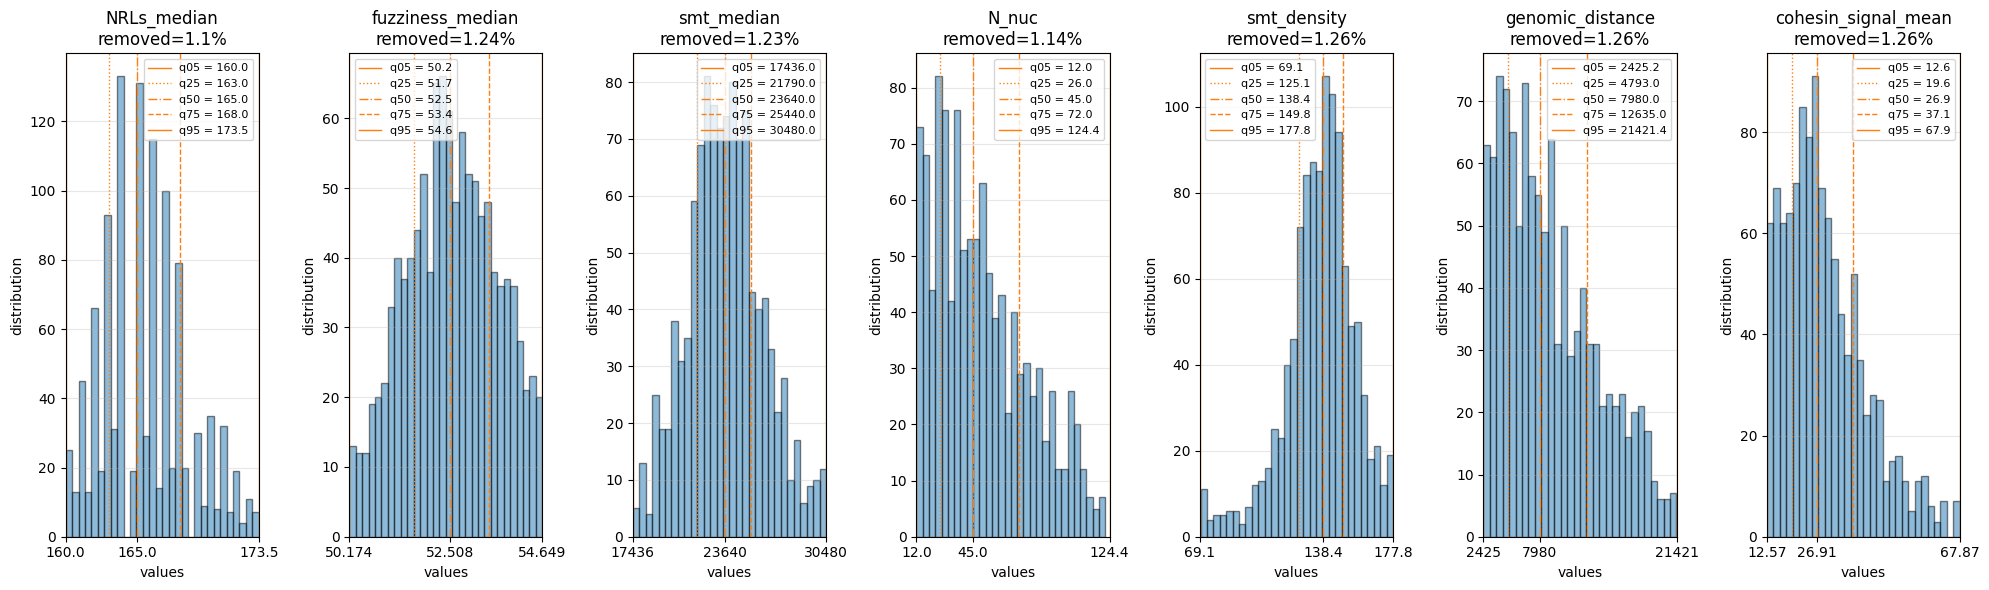

In [123]:
# This cell allows us to create a Parquet file containing each of the quartiles for each column of interest.
# The Parquet file will be used to visualise the distribution of values for each column of interest and to calculate the quartiles.


# ── Imports ──────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import polars as pl


# ── DataFrame ──────────────────────────────────────────────────────────────────

df_CARs_NUCLEO = pl.read_parquet("df_CARs_NUCLEO.parquet")


# ── Prelimenary Analysis ──────────────────────────────────────────────────────

fig, axes = plt.subplots(figsize=(20, 6), ncols=7, nrows=1)

COLUMNS         = ["NRLs_median", "fuzziness_median", "smt_median", "N_nuc", "smt_density", "genomic_distance", "cohesin_signal_mean"]
dict_quartiles  = {"quartiles": [0.05, 0.25, 0.5, 0.75, 0.95]}
dict_quartiles.update({col: [] for col in COLUMNS})

for ax, col in zip(axes, COLUMNS):

    # Suppression des NaN / inf
    values = df_CARs_NUCLEO[col].to_numpy()
    values = values[np.isfinite(values)]

    # "Je retire les extrêmes pour visualiser la distribution centrale et éviter que l'échelle soit dominée par les outliers.
    q05, q25, q50, q75, q95 = np.percentile(
        values,
        [5, 25, 50, 75, 95]
    )
    values_plot = values[(values >= q05) & (values <= q95)]
    vmin, vmax = q05, q95
    n = len(values)
    n_removed = (n - len(values_plot)) / 100

    # Quartiles
    dict_quartiles[col] = np.array([q05, q25, q50, q75, q95], dtype=np.float64)
    ax.axvline(q05, color="tab:orange", linestyle="-", linewidth=1, label=f"q05 = {q05:.1f}")
    ax.axvline(q25, color="tab:orange", linestyle=":", linewidth=1, label=f"q25 = {q25:.1f}")
    ax.axvline(q50, color="tab:orange", linestyle="-.", linewidth=1, label=f"q50 = {q50:.1f}")
    ax.axvline(q75, color="tab:orange", linestyle="--", linewidth=1, label=f"q75 = {q75:.1f}")
    ax.axvline(q95, color="tab:orange", linestyle="-", linewidth=1, label=f"q95 = {q95:.1f}")

    # Histogramme
    ax.hist(values_plot, bins=30, edgecolor="black", alpha=0.5)

    # Plot
    ax.set_xticks([vmin, q50, vmax])
    ax.set_xlim(vmin, vmax)
    ax.set_xlabel("values")
    ax.set_ylabel("distribution")
    ax.set_title(f"{col}\nremoved={n_removed}%")
    ax.grid(True, which="both", alpha=0.30)
    ax.legend(fontsize=8)

df_quartiles = pl.DataFrame(dict_quartiles)
df_quartiles.write_parquet("df_quartiles.parquet")
print(df_quartiles)
plt.tight_layout()
plt.show()

## Hic Maps sur les NNCARs

INFO:root:creating a Pool of 8 workers


INFO:coolpuppy:('chrI', 'chrI'): 11
INFO:coolpuppy:('chrIII', 'chrIII'): 19
INFO:coolpuppy:('chrVI', 'chrVI'): 14
INFO:coolpuppy:('chrV', 'chrV'): 37
INFO:coolpuppy:('chrII', 'chrII'): 56
INFO:coolpuppy:('chrIX', 'chrIX'): 32
INFO:coolpuppy:('chrXI', 'chrXI'): 44
INFO:coolpuppy:('chrVIII', 'chrVIII'): 35
INFO:coolpuppy:('chrVII', 'chrVII'): 74
INFO:coolpuppy:('chrX', 'chrX'): 58
INFO:coolpuppy:('chrXIV', 'chrXIV'): 51
INFO:coolpuppy:('chrXV', 'chrXV'): 77
INFO:coolpuppy:('chrXII', 'chrXII'): 73
INFO:coolpuppy:('chrXVI', 'chrXVI'): 66
INFO:coolpuppy:('chrXIII', 'chrXIII'): 62
INFO:coolpuppy:('chrIV', 'chrIV'): 106
INFO:coolpuppy:Total number of piled up windows: 815


<Axes: title={'center': ' 2425.2 =< *** < 4793.0'}, xlabel='relative position (kbp)'>

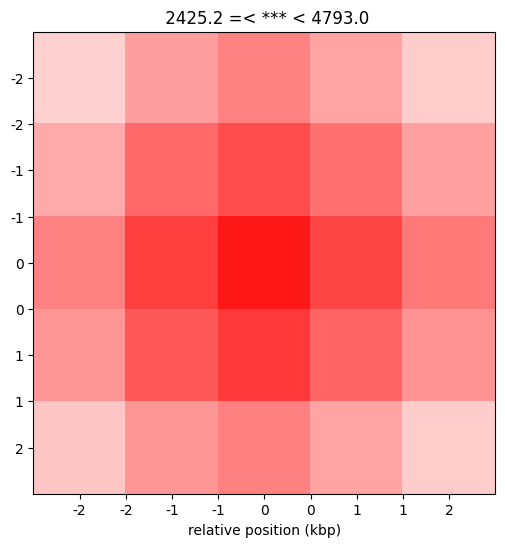

In [164]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bio
import cooler
import cooltools
from coolpuppy.coolpup import pileup as cpp_pileup


# ── Global Values ──────────────────────────────────────────────────────────────────

# Window size NB this is also the minimal distance between CARs that will be considered
# If you consider too many low strength CARs that may be a problem
RESOLUTION      = 1000
FLANK           = 2000 
PATH            = "/home/nicolas/Documents/Workspace/nucleo/"


# ── Data ──────────────────────────────────────────────────────────────────

DF_CARS_NUCLEO  =  pd.read_parquet(
    PATH + "notebooks/cars/df_CARs_NUCLEO.parquet"
)

CLR = cooler.Cooler(
    PATH +  f"outputs/NUC/AD908_G2_mixed.mcool::/resolutions/{RESOLUTION}"
)

VIEW_DF = pd.DataFrame({
    "chrom": CLR.chromnames,
    "start": 0,
    "end": CLR.chromsizes.values,
    "name": CLR.chromnames
})

CVD = cooltools.expected_cis(
    clr=CLR,
    view_df=VIEW_DF,
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=False,
    nproc=8
)


# ── Hi-C Function ───────────────────────────────────────────────────────────

def show_hic(
    df_cars_nucleo=DF_CARS_NUCLEO, 
    clr=CLR, 
    view_df=VIEW_DF, 
    cvd=CVD, 
    flank=FLANK, 
    resolution=RESOLUTION,
    ax=None
    ):

    # ── Fig
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # ── Read Hi-C data 
     
    pup = cpp_pileup(
        clr,
        df_cars_nucleo,
        features_format="bedpe",
        flank=FLANK,
        view_df=view_df,
        expected_df=cvd,
        expected_value_col="count.avg.smoothed",
        clr_weight_name=None,
        nproc=8,
    )

    # ── Plot Hi-C data 

    mtx = pup.loc[0, 'data']
    im = ax.imshow(
        np.log2(mtx),
        cmap='bwr',
        vmin=-1,
        vmax=1,
        interpolation='none'
    )

    ticks_pixels = np.linspace(0, flank * 2 // resolution, 9)
    ticks_kbp = ((ticks_pixels - ticks_pixels[-1] / 2) * resolution // 1000).astype(int)
    ax.set(
        xticks=ticks_pixels,
        xticklabels=ticks_kbp,
        yticks=ticks_pixels,
        yticklabels=ticks_kbp,
        xlabel='relative position (kbp)',
        title=(
            f" {vmin:.1f} =< *** < {vmax:.1f}"
        ),
    )
            
    return ax


# ── Filtering Function ───────────────────────────────────────────────────────────

def filter_DataFrame_by_values(
    df_data: pl.DataFrame, 
    key: str,
    vmin: int,
    vmax: int
) -> pl.DataFrame:
    """Filter a DataFrame by values.

    Args:
        df_data (pl.DataFrame): DataFrame to filter.
        key (str): Column name to filter on.
        vmin (int): Minimum value to filter on.
        vmax (int): Maximum value to filter on.

    Returns:
        pl.DataFrame: Filtered DataFrame.
    """

    df_filtered = df_data.filter(
        (pl.col(key) >= vmin) & (pl.col(key) < vmax)
    )
    
    return df_filtered.to_pandas()


# ── Call ───────────────────────────────────────────────────────────

show_hic(DF_CARS_NUCLEO, CLR, flank=FLANK, resolution=RESOLUTION)

INFO:coolpuppy:('chrI', 'chrI'): 3
INFO:coolpuppy:('chrIII', 'chrIII'): 2
INFO:coolpuppy:('chrVI', 'chrVI'): 1
INFO:coolpuppy:('chrIX', 'chrIX'): 5
INFO:coolpuppy:('chrX', 'chrX'): 6
INFO:coolpuppy:('chrVIII', 'chrVIII'): 2
INFO:coolpuppy:('chrV', 'chrV'): 5
INFO:coolpuppy:('chrII', 'chrII'): 9
INFO:coolpuppy:('chrVII', 'chrVII'): 11
INFO:coolpuppy:('chrXIII', 'chrXIII'): 7
INFO:coolpuppy:('chrXI', 'chrXI'): 6
INFO:coolpuppy:('chrXIV', 'chrXIV'): 10
INFO:coolpuppy:('chrXVI', 'chrXVI'): 6
INFO:coolpuppy:('chrXV', 'chrXV'): 10
INFO:coolpuppy:('chrIV', 'chrIV'): 18
INFO:coolpuppy:('chrXII', 'chrXII'): 13
INFO:coolpuppy:Total number of piled up windows: 114
INFO:coolpuppy:('chrI', 'chrI'): 2
INFO:coolpuppy:('chrVI', 'chrVI'): 2
INFO:coolpuppy:('chrIX', 'chrIX'): 9
INFO:coolpuppy:('chrIII', 'chrIII'): 3
INFO:coolpuppy:('chrXI', 'chrXI'): 11
INFO:coolpuppy:('chrX', 'chrX'): 11
INFO:coolpuppy:('chrVIII', 'chrVIII'): 9
INFO:coolpuppy:('chrII', 'chrII'): 16
INFO:coolpuppy:('chrV', 'chrV'): 8
IN

ValueError: No chromosomes are in common between the coordinate
                   file and the cooler file. Are they in the same
                   format, e.g. starting with "chr"?
                   

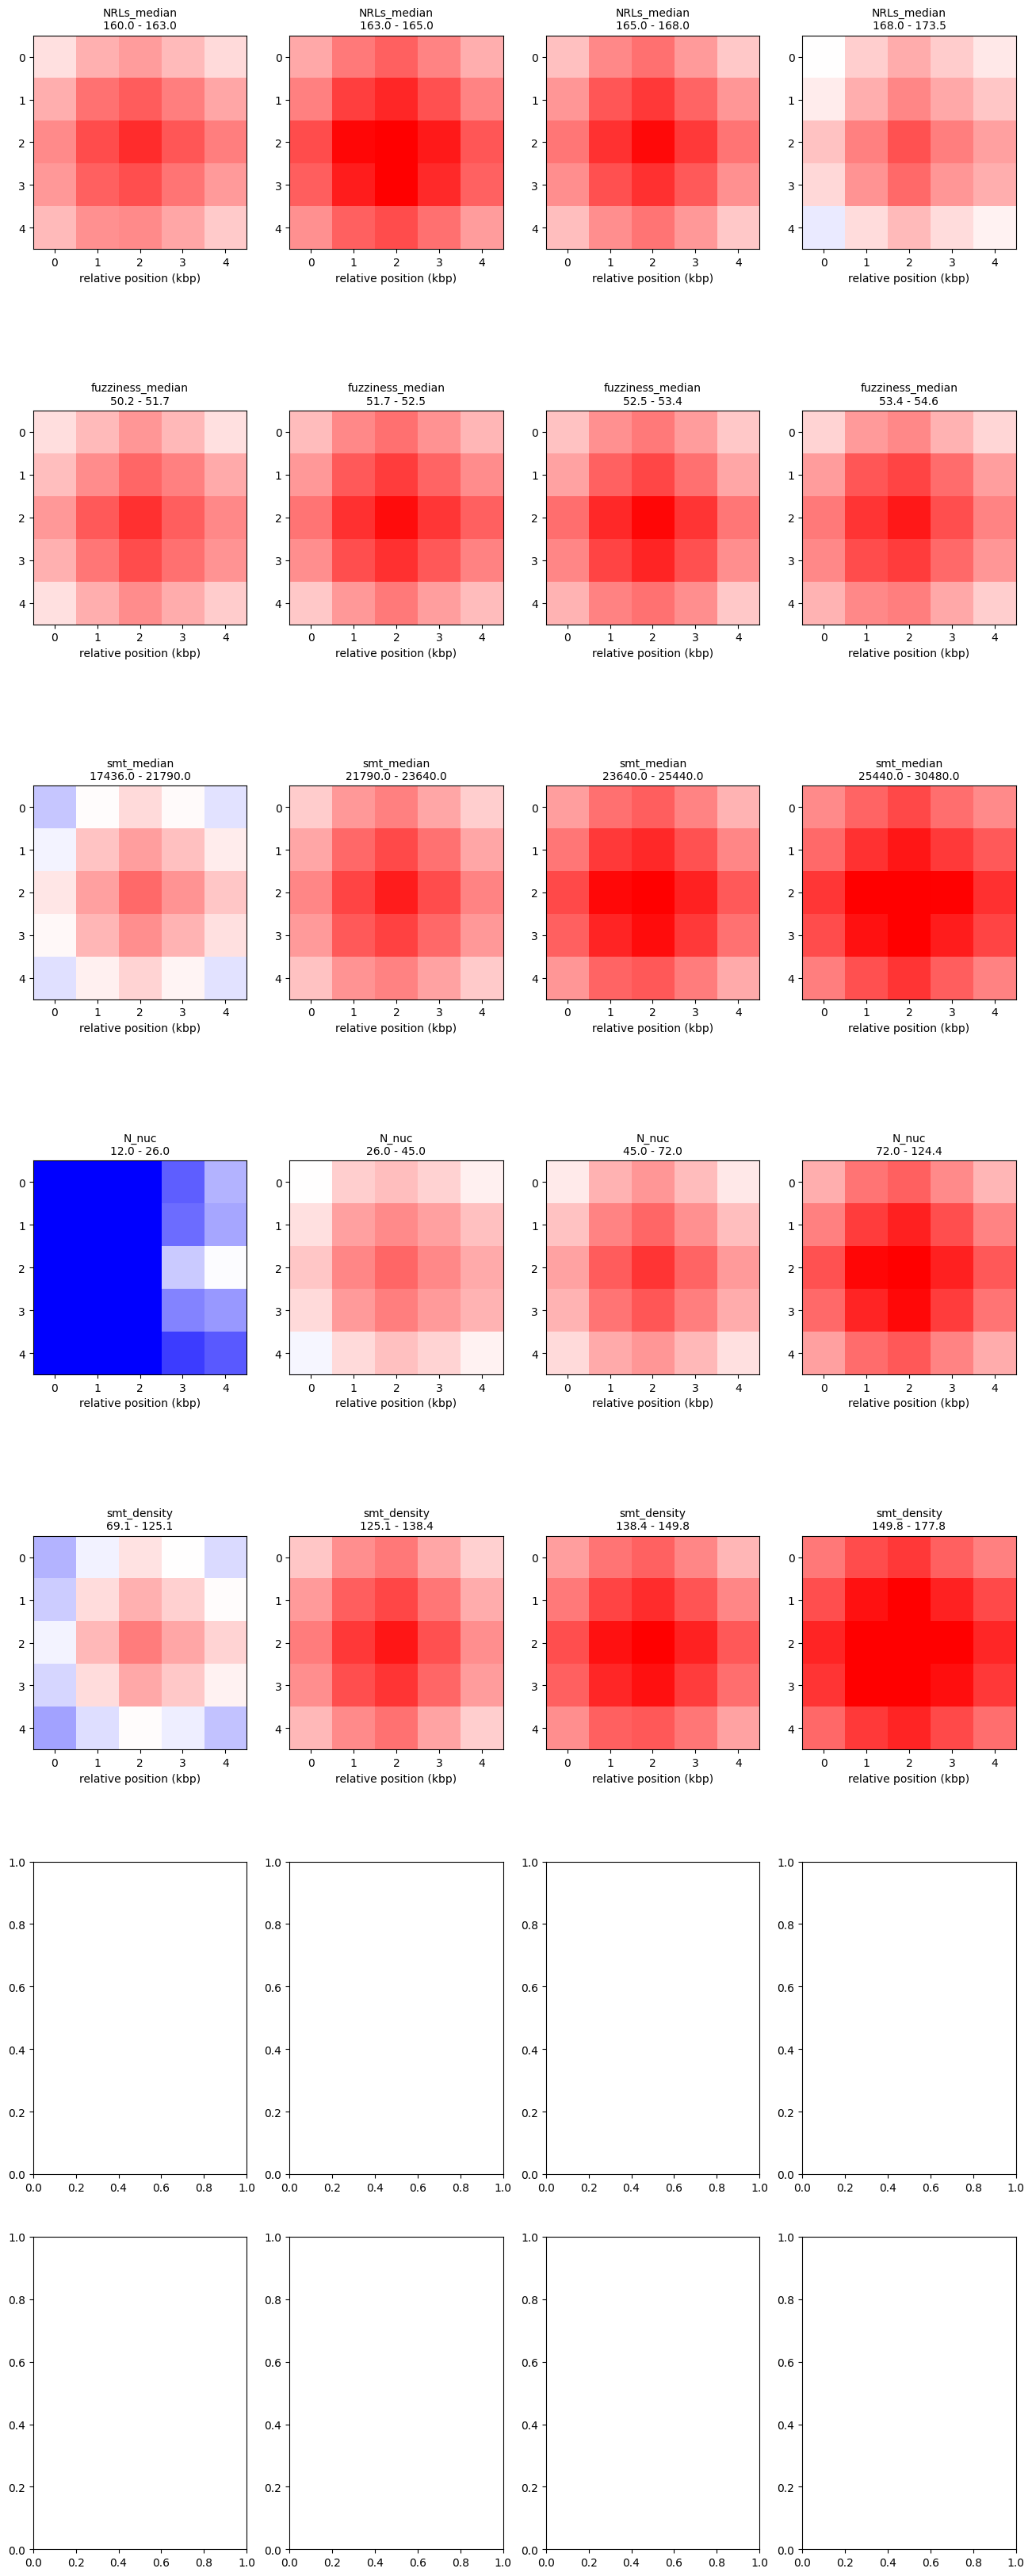

In [ ]:
# ── Final Call ───────────────────────────────────────────────────────────

QUARTERS = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(
    figsize=(16, 6 * len(COLUMNS)),
    ncols=len(QUARTERS)-1,
    nrows=len(COLUMNS)
)

axes = np.atleast_2d(axes)

for i, value in enumerate(COLUMNS):
    
    for j, quarter in enumerate(QUARTERS[:-1]):

        ax = axes[i, j]

        vmin = df_quartiles[value][quarter]
        vmax = df_quartiles[value][quarter + 1]

        df_single = filter_DataFrame_by_values(
            df_data=df_CARs_NUCLEO,
            key=value,
            vmin=vmin,
            vmax=vmax
        )

        show_hic(
            df_single,
            CLR,
            flank=FLANK,
            resolution=RESOLUTION,
            ax=ax
        )

        ax.set_title(
            f"{value}\n{vmin:.1f} - {vmax:.1f}",
            fontsize=10
        )

plt.tight_layout()
plt.show()

## HiC Map

/tmp/ipykernel_27153/3395831196.py:4: RuntimeWarning: divide by zero encountered in log2
  np.log2(mtx_2),


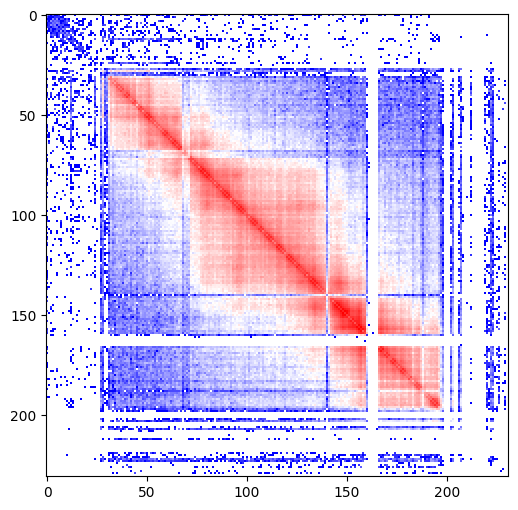

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
mtx_2=clr.matrix(balance=False).fetch("chrI")
im=ax.imshow(
    np.log2(mtx_2),
    cmap='bwr',
    # vmin=-1,
    # vmax=1,
interpolation='none')

# .